# Step2: Permana 2025スタイルの22特徴量への拡張

**前提**: このnotebookの前に、Step1 (MNE tutorialそのまま) のセルを実行し、
`epochs_train` (Alice) と `epochs_test` (Bob) が変数として存在していること。

**このnotebookで追加すること**:
- `src/features.py` に `extract_permana_features()` を追加 (新規関数、既存の`eeg_power_band`は無変更)
- 同じ `RandomForestClassifier(n_estimators=100, random_state=42)` で学習し、Step1と条件を揃えて比較する
- 変更点: 特徴量だけ (5個 → 22個)。分類器・train/testの分け方はStep1と同一。

**新規ライブラリ**: `antropy` (エントロピー計算), `pywavelets` (wavelet分解)


In [2]:
# 新規ライブラリのインストール (Step2で初めて必要になったもの)
!pip install antropy pywavelets -q


In [3]:
!pip install -q mne

In [1]:
import sys
print(sys.executable)
print(sys.version)

/opt/anaconda3/bin/python
3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:28:27) [Clang 14.0.6 ]


In [2]:
import mne
print(mne.__version__)

1.12.1


## Step1データの読み込み (このnotebookを単体で実行できるようにするため追加)

**追加理由**: このnotebookを単体で開くと `epochs_train` / `epochs_test` が存在せず
`NameError` になるため。Step1 tutorialのデータ読み込みセルをそのまま (無変更で) ここに追加する。

**注意**: 中身はStep1で実行したコードと完全に同一。`eeg_power_band`の呼び出しはしていない
(Step1notebook側でのみ使う)ため、ここでは読み込みとepoch化までを行う。


In [5]:
import mne
from mne.datasets.sleep_physionet.age import fetch_data

ALICE, BOB = 0, 1
[alice_files, bob_files] = fetch_data(subjects=[ALICE, BOB], recording=[1])

annotation_desc_2_event_id = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4,
    "Sleep stage 4": 4,
    "Sleep stage R": 5,
}
event_id = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3/4": 4,
    "Sleep stage R": 5,
}

# --- Alice (train) ---
raw_train = mne.io.read_raw_edf(
    alice_files[0], stim_channel="Event marker", infer_types=True,
    preload=True, verbose="error",
)
annot_train = mne.read_annotations(alice_files[1])
annot_train.crop(annot_train[1]["onset"] - 30 * 60, annot_train[-2]["onset"] + 30 * 60)
raw_train.set_annotations(annot_train, emit_warning=False)
events_train, _ = mne.events_from_annotations(
    raw_train, event_id=annotation_desc_2_event_id, chunk_duration=30.0
)
tmax = 30.0 - 1.0 / raw_train.info["sfreq"]
epochs_train = mne.Epochs(
    raw=raw_train, events=events_train, event_id=event_id,
    tmin=0.0, tmax=tmax, baseline=None,
)
del raw_train

# --- Bob (test) ---
raw_test = mne.io.read_raw_edf(
    bob_files[0], stim_channel="Event marker", infer_types=True,
    preload=True, verbose="error",
)
annot_test = mne.read_annotations(bob_files[1])
annot_test.crop(annot_test[1]["onset"] - 30 * 60, annot_test[-2]["onset"] + 30 * 60)
raw_test.set_annotations(annot_test, emit_warning=False)
events_test, _ = mne.events_from_annotations(
    raw_test, event_id=annotation_desc_2_event_id, chunk_duration=30.0
)
epochs_test = mne.Epochs(
    raw=raw_test, events=events_test, event_id=event_id,
    tmin=0.0, tmax=tmax, baseline=None,
)
del raw_test

print(epochs_train)
print(epochs_test)


Using default location ~/mne_data for PHYSIONET_SLEEP...
Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Not setting metadata
841 matching events found
No baseline correction applied
0 projection items activated
Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Not setting metadata
1103 matching events found
No baseline correction applied
0 projection items activated
<Epochs | 841 events (good & bad), 0 – 29.99 s (baseline off), ~10 KiB, data not loaded,
 'Sleep stage W': 188
 'Sleep stage 1': 58
 'Sleep stage 2': 250
 'Sleep stage 3/4': 220
 'Sleep stage R': 125>
<Epochs | 1103 events (good & bad), 0 – 29.99 s (baseline off), ~10 KiB, data not loaded,
 'Sleep stage W': 157
 'Sleep stage 1': 109
 'Sleep stage 2':

## `src/features.py` のインポート (GitHub管理版)

`src/features.py` はGitHubリポジトリ (`sleep-xai`) で管理しているため、
`%%writefile`は使わず、リポジトリをcloneしてimportする。

**変更点 (前バージョンからの差分)**:
- 削除: `%%writefile src/features.py` セル
- 追加: `git clone` でリポジトリを取得し、既存の `src/features.py` をそのままimportする方式
- `src/features.py` の中身自体は一切変更していません

⚠️ **リポジトリがprivateのため、このセルを実行する前に一時的にpublicに切り替えてください**
(GitHub → Settings → General → Danger Zone → Change repository visibility)。
実行後はprivateに戻して問題ありません。認証を使ったclone(SSH鍵 / Personal Access Token)は、
必要になったタイミングで改めて提案します。


In [ ]:
print("test")

: 

In [6]:
import os
print(os.getcwd())

/Users/naokingu/Documents/sleep-xai/notebooks


In [7]:
import os
os.chdir("..")
print(os.getcwd())

/Users/naokingu/Documents/sleep-xai


In [6]:
import sys
sys.path.append(".")

from src.features import eeg_power_band, extract_permana_features, PERMANA_FEATURE_NAMES

print("特徴量一覧（22個）:")
print(PERMANA_FEATURE_NAMES)

特徴量一覧（22個）:
['mean', 'variance', 'skewness', 'kurtosis', 'shannon_entropy', 'permutation_entropy', 'sample_entropy', 'spindle_count', 'kcomplex_count', 'ratio_theta_alpha', 'ratio_delta_beta', 'ratio_thetaalpha_beta', 'bp_delta', 'bp_theta', 'bp_alpha', 'bp_sigma', 'bp_beta', 'wavelet_energy_d1', 'wavelet_energy_d2', 'wavelet_energy_d3', 'wavelet_energy_d4', 'wavelet_energy_d5']


## 特徴量抽出 (Step1の`epochs_train`, `epochs_test`をそのまま再利用)

`eeg_power_band`をPSD経由で計算していたのに対し、`extract_permana_features`は
生波形からエポックごとにループして計算するため、少し時間がかかります
(841 + 1103エポックで数十秒〜数分程度が目安)。


In [7]:
X_train_p2 = extract_permana_features(epochs_train, verbose=True)
X_test_p2 = extract_permana_features(epochs_test, verbose=True)

print("X_train_p2.shape =", X_train_p2.shape)
print("X_test_p2.shape  =", X_test_p2.shape)


Using data from preloaded Raw for 841 events and 3000 original time points ...
0 bad epochs dropped
  200/841 エポック完了
  400/841 エポック完了
  600/841 エポック完了
  800/841 エポック完了
Using data from preloaded Raw for 1103 events and 3000 original time points ...
0 bad epochs dropped
  200/1103 エポック完了
  400/1103 エポック完了
  600/1103 エポック完了
  800/1103 エポック完了
  1000/1103 エポック完了
X_train_p2.shape = (841, 22)
X_test_p2.shape  = (1103, 22)


## 学習・評価 (Step1と同じRandomForest設定で比較)

Step1では `make_pipeline(FunctionTransformer(eeg_power_band), RandomForestClassifier(...))` を
使っていましたが、ここでは既に特徴量抽出済みの `X_train_p2` を直接学習に使います
(FunctionTransformerを介すると`extract_permana_features`が呼ばれるたびに再計算されて遅いため)。
分類器の設定 (`n_estimators=100, random_state=42`) はStep1と完全に揃えています。


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_train = epochs_train.events[:, 2]
y_test = epochs_test.events[:, 2]

clf_p2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_p2.fit(X_train_p2, y_train)
y_pred_p2 = clf_p2.predict(X_test_p2)

acc_p2 = accuracy_score(y_test, y_pred_p2)
print(f"Step2 (22特徴量) Accuracy: {acc_p2:.3f}")
print(f"(Step1 (5特徴量) Accuracy: 0.685 <- tutorialでの結果)")
print()
print(classification_report(y_test, y_pred_p2, target_names=event_id.keys()))
print(confusion_matrix(y_test, y_pred_p2))


Step2 (22特徴量) Accuracy: 0.714
(Step1 (5特徴量) Accuracy: 0.685 <- tutorialでの結果)

                 precision    recall  f1-score   support

  Sleep stage W       0.45      0.44      0.45       157
  Sleep stage 1       0.56      0.31      0.40       109
  Sleep stage 2       0.87      0.87      0.87       562
Sleep stage 3/4       0.51      0.99      0.68       105
  Sleep stage R       0.75      0.53      0.62       170

       accuracy                           0.71      1103
      macro avg       0.63      0.63      0.60      1103
   weighted avg       0.72      0.71      0.71      1103

[[ 69   3  30  54   1]
 [ 36  34  18   0  21]
 [ 13   6 490  45   8]
 [  0   0   1 104   0]
 [ 35  18  27   0  90]]


## 確認ポイント

- Step1 (0.685) と比べてAccuracyがどう変化したか
- どのステージのprecision/recallが改善/悪化したか
  (例: Stage 1の分類は難しいことが多いので、そこが伸びたかは要確認)
- 次のStep3 (RF vs XGBoost比較) に進む前に、この22特徴量の結果を記録しておく


In [11]:
!pip install shap -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.


SHAP適用

In [10]:
import numpy as np

def normalize_shap_values(shap_values, n_classes, n_features):
    """常に (n_classes, n_samples, n_features) の形状に正規化する。"""
    if isinstance(shap_values, list):
        return np.stack(shap_values, axis=0)

    arr = np.asarray(shap_values)

    if arr.ndim == 2:
        return arr[None, ...]

    if arr.ndim == 3:
        shape = arr.shape
        if shape[0] == n_classes and shape[2] == n_features:
            return arr
        if shape[-1] == n_classes and shape[1] == n_features:
            return np.transpose(arr, (2, 0, 1))
        if shape[1] == n_classes and shape[2] == n_features:
            return np.transpose(arr, (1, 0, 2))

    raise ValueError(f"想定外のSHAP出力形状です: {arr.shape}")

In [11]:
import shap

explainer = shap.TreeExplainer(clf_p2)

shap_values_raw = explainer.shap_values(X_test_p2)

shap_values = normalize_shap_values(
    shap_values_raw,
    n_classes=len(event_id),
    n_features=X_test_p2.shape[1]
)

print(shap_values.shape)

(5, 1103, 22)


In [12]:
import numpy as np
import os

os.makedirs("results", exist_ok=True)
np.save("results/shap_values.npy", np.array(shap_values))
np.save("results/X_test.npy", np.array(X_test_p2))
np.save("results/y_test.npy", np.array(y_test))

print("保存完了")

保存完了


In [13]:
np.save("results/X_train.npy", np.array(X_train_p2))
np.save("results/y_train.npy", np.array(y_train))

In [26]:
shap_values_loaded = np.load("results/shap_values.npy")
X_test_loaded = np.load("results/X_test.npy")
y_test_loaded = np.load("results/y_test.npy")

print(shap_values_loaded.shape)  # (5, 1103, 22) になるはず
print(X_test_loaded.shape)       # (1103, 22)
print(y_test_loaded.shape)       # (1103,)

(5, 1103, 22)
(1103, 22)
(1103,)


In [28]:
import numpy as np
print(np.unique(y_test_loaded))

[1 2 3 4 5]


In [32]:
shap_n3 = shap_values[n3_idx]

セル3(Wake→N3誤分類の診断:ここが本題)

In [33]:
import pandas as pd

target_names = list(event_id.keys())
n3_idx = target_names.index("Sleep stage 3/4")

# 正解Wake・予測N3(誤分類) と 正解Wake・予測Wake(正しい) を比較
mis_idx = np.where((y_test == 1) & (y_pred_p2 == 4))[0]
correct_idx = np.where((y_test == 1) & (y_pred_p2 == 1))[0]
print(f"Wake→N3 誤分類: {len(mis_idx)}件 / 正しくWake: {len(correct_idx)}件")

shap_n3 = shap_values[n3_idx]  # N3クラスへのSHAP値, shape (n_test, 22)

df_compare = pd.DataFrame({
    "feature": PERMANA_FEATURE_NAMES,
    "mean_shap_誤分類(Wake→N3)": shap_n3[mis_idx].mean(axis=0),
    "mean_shap_正解Wake": shap_n3[correct_idx].mean(axis=0),
})
df_compare["diff"] = df_compare["mean_shap_誤分類(Wake→N3)"] - df_compare["mean_shap_正解Wake"]
df_compare.sort_values("diff", ascending=False)

Wake→N3 誤分類: 74件 / 正しくWake: 50件


,feature,mean_shap_誤分類(Wake→N3),mean_shap_正解Wake,diff
10,ratio_delta_beta,1.064547e-01,-0.019351,1.258055e-01
16,bp_beta,7.890538e-02,-0.006563,8.546811e-02
1,variance,1.030228e-01,0.033786,6.923709e-02
5,permutation_entropy,-3.397466e-02,-0.089549,5.557475e-02
21,wavelet_energy_d5,4.598905e-02,-0.001708,4.769730e-02
11,ratio_thetaalpha_beta,1.908780e-03,-0.031823,3.373132e-02
20,wavelet_energy_d4,1.514635e-02,-0.004897,2.004361e-02
6,sample_entropy,3.598731e-02,0.015979,2.000880e-02
13,bp_theta,1.649539e-02,0.004200,1.229519e-02
4,shannon_entropy,-3.655555e-03,-0.015031,1.137572e-02


セル4(Global重要度も一応可視化)

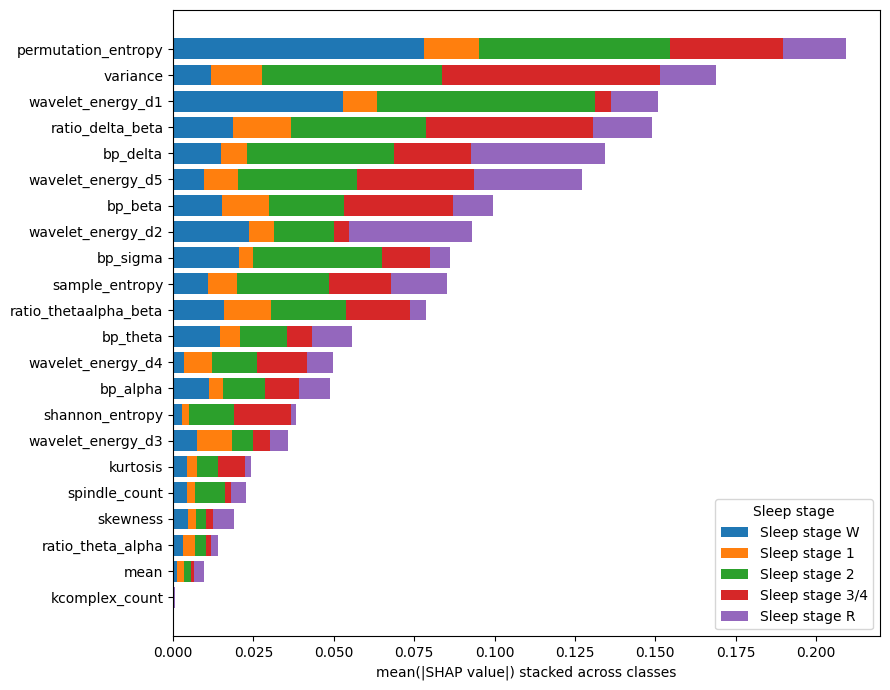

In [34]:
import matplotlib.pyplot as plt

mean_abs_shap = np.mean(np.abs(shap_values), axis=1)  # (n_classes, n_features)
order = np.argsort(mean_abs_shap.mean(axis=0))[::-1]

fig, ax = plt.subplots(figsize=(9, 7))
bottom = np.zeros(len(PERMANA_FEATURE_NAMES))
x_pos = np.arange(len(PERMANA_FEATURE_NAMES))
for ci, cname in enumerate(target_names):
    vals = mean_abs_shap[ci, order]
    ax.barh(x_pos, vals, left=bottom[order] if ci > 0 else None, label=cname)
    bottom += mean_abs_shap[ci] if ci > 0 else mean_abs_shap[ci]
ax.set_yticks(x_pos); ax.set_yticklabels([PERMANA_FEATURE_NAMES[i] for i in order])
ax.invert_yaxis()
ax.set_xlabel("mean(|SHAP value|) stacked across classes")
ax.legend(title="Sleep stage", loc="lower right")
plt.tight_layout()
plt.show()

ここからは各睡眠段階の特徴量ランキングをSHAPで取得していく。

In [29]:
import pandas as pd
import numpy as np

target_names = list(event_id.keys())  # ['Sleep stage W', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3/4', 'Sleep stage R']

for class_idx, class_name in enumerate(target_names):
    mean_abs_shap = np.abs(shap_values[class_idx]).mean(axis=0)  # shape: (22,)
    
    df_importance = pd.DataFrame({
        "feature": PERMANA_FEATURE_NAMES,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)
    
    print(f"\n===== {class_name} の重要特徴量 Top10 =====")
    print(df_importance.head(10).to_string(index=False))


===== Sleep stage W の重要特徴量 Top10 =====
              feature  mean_abs_shap
  permutation_entropy       0.096498
             bp_sigma       0.044908
ratio_thetaalpha_beta       0.031872
     ratio_delta_beta       0.026753
             bp_theta       0.025824
             bp_alpha       0.025242
              bp_beta       0.020658
             bp_delta       0.018894
             skewness       0.011052
        spindle_count       0.009989

===== Sleep stage 1 の重要特徴量 Top10 =====
              feature  mean_abs_shap
  permutation_entropy       0.024204
              bp_beta       0.023640
     ratio_delta_beta       0.021618
ratio_thetaalpha_beta       0.018090
             bp_delta       0.009878
             bp_theta       0.009518
       sample_entropy       0.008583
             bp_alpha       0.008466
             bp_sigma       0.007702
        spindle_count       0.006831

===== Sleep stage 2 の重要特徴量 Top10 =====
              feature  mean_abs_shap
             bp_sigma       0

In [30]:
!cat .gitignore

# Python
__pycache__/
*.pyc
.ipynb_checkpoints/

# Data
datasets/
data/
*.edf
*.EDF

# Outputs
outputs/
figures/
models/
results/

# Environment
.env
.venv/
venv/

# Mac
.DS_Store


In [ ]:
import numpy as np
import scipy
import sklearn
print(np.__version__, scipy.__version__, sklearn.__version__)

from sklearn.ensemble import RandomForestClassifier
print("OK")

In [ ]:
!pip install --upgrade --force-reinstall pandas

In [15]:
import numpy as np
# 全クラス平均の mean(|SHAP|) を計算（棒グラフやランキングの土台）
mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 1))  # shape: (22,)
print(mean_abs_shap.shape)  # (22,) と出ればOK

(22,)


In [16]:
# Global SHAP Importance
global_shap = pd.DataFrame({
    "feature": PERMANA_FEATURE_NAMES,
    "importance": mean_abs_shap
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(global_shap)

,feature,importance
0,permutation_entropy,0.052390
1,ratio_delta_beta,0.037812
2,bp_sigma,0.034175
3,bp_delta,0.032539
4,bp_beta,0.029673
5,ratio_thetaalpha_beta,0.025306
6,sample_entropy,0.025159
7,bp_alpha,0.021104
8,bp_theta,0.020125
9,shannon_entropy,0.011576


In [17]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# 前セルのGlobal Importance(スタック棒グラフ)から読み取ったランキング
top10_features = ["permutation_entropy", "variance", "wavelet_energy_d1", "ratio_delta_beta",
                   "bp_delta", "wavelet_energy_d5", "bp_beta", "wavelet_energy_d2",
                   "bp_sigma", "sample_entropy"]

top5_features = ["permutation_entropy", "variance", "wavelet_energy_d1", "ratio_delta_beta", "bp_delta"]


def run_experiment(feature_subset, label, seed=42):
    idx = [PERMANA_FEATURE_NAMES.index(f) for f in feature_subset]

    X_train_sub = X_train_p2[:, idx]
    X_test_sub = X_test_p2[:, idx]

    model = RandomForestClassifier(n_estimators=100, random_state=seed)

    t0 = time.time()
    model.fit(X_train_sub, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_test_sub)
    infer_time = time.time() - t0

    return {
        "setting": label,
        "n_features": len(feature_subset),
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "train_time_sec": train_time,
        "infer_time_sec": infer_time,
    }


results = []
results.append(run_experiment(PERMANA_FEATURE_NAMES, "全22特徴量(ベースライン)"))
results.append(run_experiment(top10_features, "SHAP上位10"))
results.append(run_experiment(top5_features, "SHAP上位5"))

df_results = pd.DataFrame(results)
df_results

,setting,n_features,accuracy,macro_f1,train_time_sec,infer_time_sec
0,全22特徴量(ベースライン),22,0.713509,0.601994,0.129188,0.006230
1,SHAP上位10,10,0.705349,0.597495,0.089601,0.005828
2,SHAP上位5,5,0.703536,0.605527,0.074127,0.005584


# Feature Selection using Global SHAP

Global SHAP Importance の順位から特徴量集合を自動生成し、元の22特徴量モデルと同じ Random Forest 設定で再学習・比較します。

In [18]:
import numpy as np
import pandas as pd

# 棒グラフと同じ (class, sample, feature) 配列を使う。
print("Raw shap_values type:", type(shap_values))
print("Raw shap_values shape:", np.asarray(shap_values).shape)

shap_values_global = normalize_shap_values(
    shap_values,
    n_classes=len(event_id),
    n_features=len(PERMANA_FEATURE_NAMES),
)
print("Normalized SHAP shape (class, sample, feature):", shap_values_global.shape)

expected_shape_parts = (len(event_id), len(PERMANA_FEATURE_NAMES))
if (shap_values_global.shape[0], shap_values_global.shape[2]) != expected_shape_parts:
    raise ValueError(
        "SHAP shape does not match classes/features: "
        f"{shap_values_global.shape}, expected (*): {expected_shape_parts}"
    )

# 既存の積み上げ棒グラフのクラス別 mean(abs(SHAP)) をクラス方向に合計する。
# mean_abs_shap は既存のクラス別解析で使われるため上書きしない。
global_importance = np.mean(
    np.abs(shap_values_global),
    axis=1,
).sum(axis=0)

# 既存グラフと同じ np.argsort(...)[::-1] を使い、同一順位を保証する。
global_order = np.argsort(global_importance)[::-1]
global_shap = pd.DataFrame({
    "rank": np.arange(1, len(global_order) + 1),
    "feature": np.asarray(PERMANA_FEATURE_NAMES)[global_order],
    "importance": global_importance[global_order],
})

display(global_shap)

Raw shap_values type: <class 'numpy.ndarray'>
Raw shap_values shape: (5, 1103, 22)
Normalized SHAP shape (class, sample, feature): (5, 1103, 22)


,rank,feature,importance
0,1,permutation_entropy,0.261952
1,2,ratio_delta_beta,0.189060
2,3,bp_sigma,0.170876
3,4,bp_delta,0.162694
4,5,bp_beta,0.148363
5,6,ratio_thetaalpha_beta,0.126529
6,7,sample_entropy,0.125796
7,8,bp_alpha,0.105518
8,9,bp_theta,0.100625
9,10,shannon_entropy,0.057878


In [19]:
from sklearn.ensemble import RandomForestClassifier

ranked_features = global_shap["feature"].tolist()
feature_sets = {
    "Top22": ranked_features[:22],
    "Top20": ranked_features[:20],
    "Top15": ranked_features[:15],
    "Top10": ranked_features[:10],
    "Top5": ranked_features[:5],
}

if len(ranked_features) < 22:
    raise ValueError(f"22 features are required, but only {len(ranked_features)} were ranked.")

# 明示値だけでなく class_weight、n_jobs などの既定値も含め、clf_p2 と完全に一致させる。
rf_params = clf_p2.get_params(deep=False)
required_rf_params = [
    "n_estimators", "random_state", "class_weight", "max_depth",
    "min_samples_split", "min_samples_leaf", "n_jobs",
]
print("Random Forest parameters copied from clf_p2:")
print({name: rf_params[name] for name in required_rf_params})
print("Feature-set sizes:", {name: len(features) for name, features in feature_sets.items()})

Random Forest parameters copied from clf_p2:
{'n_estimators': 100, 'random_state': 42, 'class_weight': None, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'n_jobs': None}
Feature-set sizes: {'Top22': 22, 'Top20': 20, 'Top15': 15, 'Top10': 10, 'Top5': 5}


In [20]:
import json
import os
import joblib
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, f1_score

os.makedirs("results", exist_ok=True)
feature_name_to_index = {name: i for i, name in enumerate(PERMANA_FEATURE_NAMES)}
class_labels = np.asarray(clf_p2.classes_)
feature_selection_rows = []
feature_selection_artifacts = {}

for setting, selected_features in feature_sets.items():
    selected_indices = [feature_name_to_index[name] for name in selected_features]
    X_train_selected = X_train_p2[:, selected_indices]
    X_test_selected = X_test_p2[:, selected_indices]

    selected_model = RandomForestClassifier(**rf_params)
    selected_model.fit(X_train_selected, y_train)
    selected_predictions = selected_model.predict(X_test_selected)
    selected_confusion_matrix = confusion_matrix(
        y_test, selected_predictions, labels=class_labels
    )

    feature_selection_rows.append({
        "setting": setting,
        "n_features": len(selected_features),
        "accuracy": accuracy_score(y_test, selected_predictions),
        "macro_f1": f1_score(y_test, selected_predictions, average="macro"),
        "cohen_kappa": cohen_kappa_score(y_test, selected_predictions),
    })
    feature_selection_artifacts[setting] = {
        "features": selected_features,
        "predictions": selected_predictions,
        "confusion_matrix": selected_confusion_matrix,
        "model": selected_model,
    }

shap_feature_selection_results = (
    pd.DataFrame(feature_selection_rows)
    .sort_values("n_features", ascending=False)
    .reset_index(drop=True)
)
baseline = shap_feature_selection_results.loc[
    shap_feature_selection_results["setting"] == "Top22"
].iloc[0]
shap_feature_selection_results["accuracy_change"] = (
    shap_feature_selection_results["accuracy"] - baseline["accuracy"]
)
shap_feature_selection_results["macro_f1_change"] = (
    shap_feature_selection_results["macro_f1"] - baseline["macro_f1"]
)
shap_feature_selection_results["kappa_change"] = (
    shap_feature_selection_results["cohen_kappa"] - baseline["cohen_kappa"]
)

shap_feature_selection_results.to_csv(
    "results/shap_feature_selection_results.csv", index=False
)
global_shap.to_csv("results/global_shap_ranking.csv", index=False)
with open("results/shap_selected_features.json", "w", encoding="utf-8") as f:
    json.dump(feature_sets, f, ensure_ascii=False, indent=2)
joblib.dump(
    feature_selection_artifacts,
    "results/shap_feature_selection_artifacts.joblib",
    compress=3,
)

display(shap_feature_selection_results)

,setting,n_features,accuracy,macro_f1,cohen_kappa,accuracy_change,macro_f1_change,kappa_change
0,Top22,22,0.706256,0.578216,0.567686,0.000000,0.000000,0.000000
1,Top20,20,0.708069,0.578050,0.567311,0.001813,-0.000166,-0.000375
2,Top15,15,0.713509,0.591261,0.580370,0.007253,0.013044,0.012684
3,Top10,10,0.719855,0.621221,0.587880,0.013599,0.043005,0.020194
4,Top5,5,0.708069,0.611479,0.582230,0.001813,0.033263,0.014544


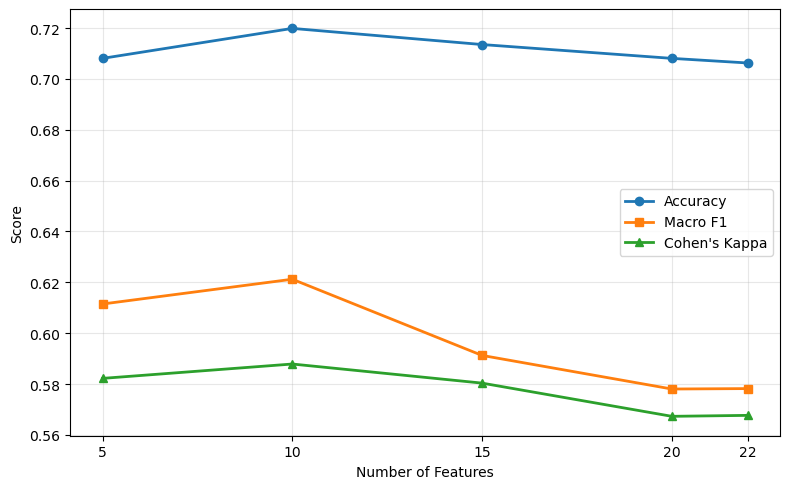

In [21]:
import matplotlib.pyplot as plt

plot_results = shap_feature_selection_results.sort_values("n_features")
fig, ax = plt.subplots(figsize=(8, 5))
for column, label, marker in [
    ("accuracy", "Accuracy", "o"),
    ("macro_f1", "Macro F1", "s"),
    ("cohen_kappa", "Cohen's Kappa", "^"),
]:
    ax.plot(
        plot_results["n_features"], plot_results[column],
        marker=marker, linewidth=2, label=label,
    )
ax.set_xlabel("Number of Features")
ax.set_ylabel("Score")
ax.set_xticks(plot_results["n_features"])
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

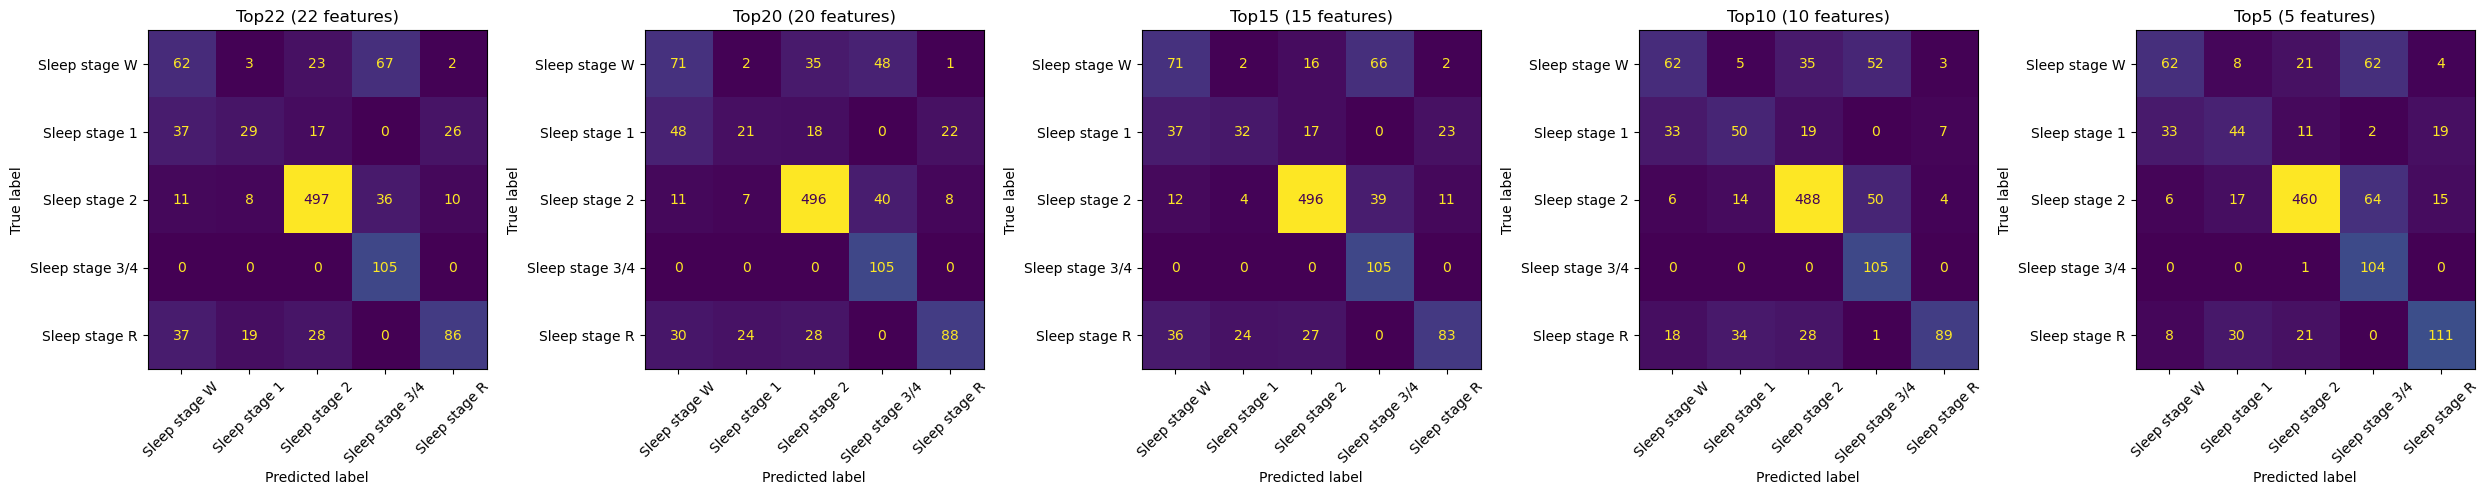

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

display_labels = [
    next((name for name, value in event_id.items() if value == label), str(label))
    for label in class_labels
]
fig, axes = plt.subplots(1, len(feature_sets), figsize=(25, 5))
for ax, (setting, artifact) in zip(axes, feature_selection_artifacts.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=artifact["confusion_matrix"],
        display_labels=display_labels,
    ).plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(f"{setting} ({len(artifact['features'])} features)")
fig.tight_layout()
plt.show()

ここは状況の確認

In [4]:
import os
print("before:", os.getcwd())
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("after :", os.getcwd())   # .../sleep-xai で終わればOK

before: /Users/naokingu/Documents/sleep-xai/notebooks
after : /Users/naokingu/Documents/sleep-xai


上で特徴量をSHAPをもとに減少させて変化を見た。次に、ランダムに特徴量を選ばせる。

In [24]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

# ランダムに k 個選んで学習・評価する（rf_params は SHAP選択と完全に同一）
def eval_feature_subset(selected_features, rf_params):
    idx = [feature_name_to_index[f] for f in selected_features]
    model = RandomForestClassifier(**rf_params)
    model.fit(X_train_p2[:, idx], y_train)
    pred = model.predict(X_test_p2[:, idx])
    return {
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "cohen_kappa": cohen_kappa_score(y_test, pred),
    }

def random_selection_trials(k, n_trials=100, master_seed=0):
    """22特徴量から k 個をランダムに選ぶ試行を n_trials 回。RFのシードは rf_params 通り固定。"""
    rng = np.random.default_rng(master_seed)
    all_features = np.asarray(PERMANA_FEATURE_NAMES)
    rows = []
    for t in range(n_trials):
        feats = list(rng.choice(all_features, size=k, replace=False))
        m = eval_feature_subset(feats, rf_params)
        m["trial"] = t
        rows.append(m)
    return pd.DataFrame(rows)

# k=10 と k=5 でランダム試行（100回ずつ）
N_TRIALS = 100
df_rand10 = random_selection_trials(10, n_trials=N_TRIALS)
df_rand5  = random_selection_trials(5,  n_trials=N_TRIALS)

# SHAP選択の値を洗練版の結果表から取り出す
def get_shap_row(n_features):
    r = shap_feature_selection_results
    return r.loc[r["n_features"] == n_features].iloc[0]

def summarize_vs_random(df_rand, k):
    shap_row = get_shap_row(k)
    out = {"k": k}
    for metric in ["accuracy", "macro_f1", "cohen_kappa"]:
        shap_val = shap_row[metric]
        rand = df_rand[metric]
        out[f"SHAP_{metric}"]      = shap_val
        out[f"rand_{metric}_mean"] = rand.mean()
        out[f"rand_{metric}_std"]  = rand.std(ddof=1)
        out[f"rand_{metric}_max"]  = rand.max()
        # 経験的p値：ランダムがSHAP以上を出した割合（小さいほどSHAPが有意に良い）
        out[f"p_{metric}"]         = float(np.mean(rand >= shap_val))
        # zスコア：SHAPがランダム分布の平均から何σ離れているか
        out[f"z_{metric}"]         = (shap_val - rand.mean()) / rand.std(ddof=1)
    return out

df_random_compare = pd.DataFrame([
    summarize_vs_random(df_rand10, 10),
    summarize_vs_random(df_rand5,  5),
])

# 見やすいように accuracy 関連だけ先に表示
acc_cols = ["k", "SHAP_accuracy", "rand_accuracy_mean", "rand_accuracy_std",
            "rand_accuracy_max", "p_accuracy", "z_accuracy"]
print("=== Accuracy: SHAP選択 vs ランダム100回 ===")
print(df_random_compare[acc_cols].to_string(index=False))
print()
f1_cols = ["k", "SHAP_macro_f1", "rand_macro_f1_mean", "rand_macro_f1_max", "p_macro_f1", "z_macro_f1"]
print("=== Macro F1 ===")
print(df_random_compare[f1_cols].to_string(index=False))

=== Accuracy: SHAP選択 vs ランダム100回 ===
 k  SHAP_accuracy  rand_accuracy_mean  rand_accuracy_std  rand_accuracy_max  p_accuracy  z_accuracy
10       0.719855            0.631732           0.074404           0.748867        0.08    1.184389
 5       0.708069            0.571904           0.082673           0.724388        0.02    1.647027

=== Macro F1 ===
 k  SHAP_macro_f1  rand_macro_f1_mean  rand_macro_f1_max  p_macro_f1  z_macro_f1
10       0.621221            0.513185           0.671040        0.04    1.770223
 5       0.611479            0.454126           0.639291        0.02    1.855307


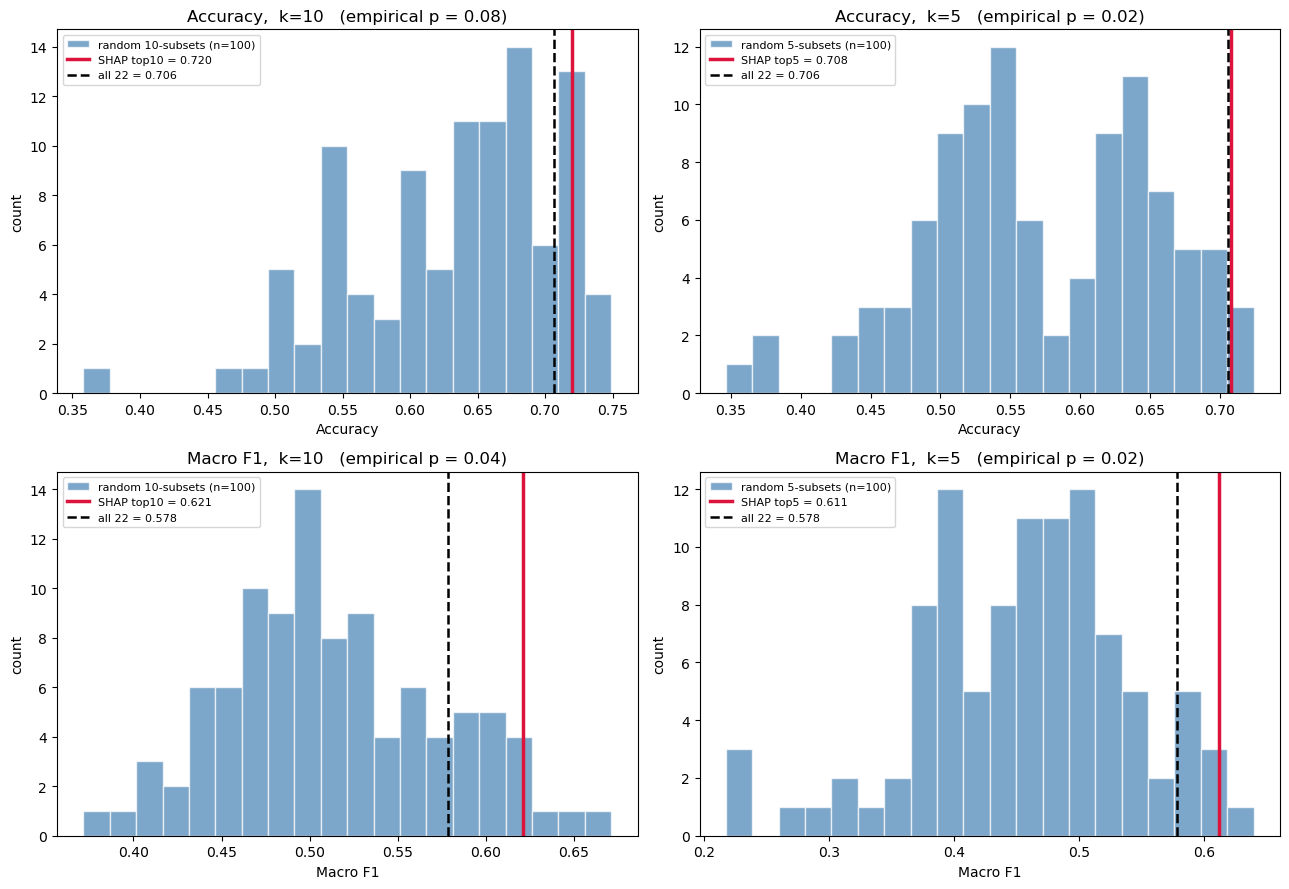

図を results/shap_vs_random_hist.png に保存しました


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
baseline_acc = get_shap_row(22)["accuracy"]
baseline_f1  = get_shap_row(22)["macro_f1"]

configs = [
    (axes[0, 0], df_rand10, 10, "accuracy",  "Accuracy",  baseline_acc),
    (axes[0, 1], df_rand5,   5, "accuracy",  "Accuracy",  baseline_acc),
    (axes[1, 0], df_rand10, 10, "macro_f1",  "Macro F1",  baseline_f1),
    (axes[1, 1], df_rand5,   5, "macro_f1",  "Macro F1",  baseline_f1),
]

for ax, df_rand, k, metric, metric_label, base_val in configs:
    shap_val = get_shap_row(k)[metric]
    ax.hist(df_rand[metric], bins=20, alpha=0.7, color="steelblue",
            edgecolor="white", label=f"random {k}-subsets (n=100)")
    ax.axvline(shap_val, color="crimson", lw=2.5, label=f"SHAP top{k} = {shap_val:.3f}")
    ax.axvline(base_val, color="black", ls="--", lw=1.8, label=f"all 22 = {base_val:.3f}")
    p = float(np.mean(df_rand[metric] >= shap_val))
    ax.set_title(f"{metric_label},  k={k}   (empirical p = {p:.2f})")
    ax.set_xlabel(metric_label)
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/shap_vs_random_hist.png", dpi=150, bbox_inches="tight")
plt.show()
print("図を results/shap_vs_random_hist.png に保存しました")

計算量的な観点も見たい

In [26]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

def measure_computation(feature_subset, label, n_repeats=20, seed=42):
    idx = [PERMANA_FEATURE_NAMES.index(f) for f in feature_subset]
    X_train_sub = X_train_p2[:, idx]
    X_test_sub = X_test_p2[:, idx]

    train_times = []
    infer_times = []
    node_counts = []

    for i in range(n_repeats):
        model = RandomForestClassifier(n_estimators=100, random_state=seed + i)

        t0 = time.perf_counter()
        model.fit(X_train_sub, y_train)
        train_times.append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        model.predict(X_test_sub)
        infer_times.append(time.perf_counter() - t0)

        # モデルの複雑さ：全木の合計ノード数(環境に依存しない計算量の代理指標)
        total_nodes = sum(tree.tree_.node_count for tree in model.estimators_)
        node_counts.append(total_nodes)

    return {
        "setting": label,
        "n_features": len(feature_subset),
        "train_time_mean": np.mean(train_times),
        "train_time_std": np.std(train_times),
        "infer_time_mean": np.mean(infer_times),
        "infer_time_std": np.std(infer_times),
        "total_nodes_mean": np.mean(node_counts),
        "total_nodes_std": np.std(node_counts),
    }

comp_results = []
comp_results.append(measure_computation(PERMANA_FEATURE_NAMES, "全22特徴量"))
comp_results.append(measure_computation(top10_features, "SHAP上位10"))
comp_results.append(measure_computation(top5_features, "SHAP上位5"))

df_comp = pd.DataFrame(comp_results)
df_comp

,setting,n_features,train_time_mean,train_time_std,infer_time_mean,infer_time_std,total_nodes_mean,total_nodes_std
0,全22特徴量,22,0.107708,0.004381,0.006382,0.000226,19170.2,162.614759
1,SHAP上位10,10,0.088751,0.000883,0.005937,0.000180,17878.5,395.351932
2,SHAP上位5,5,0.075085,0.000697,0.005732,0.000122,17129.1,639.279117


In [27]:
import time
import numpy as np
import pandas as pd
import sys
from sklearn.ensemble import RandomForestClassifier

def measure_complexity_and_time(selected_features, setting_label, rf_params,
                                 n_time_repeats=15):
    """1つの特徴量セットについて、時間（複数回測定の中央値）とモデル複雑さを測る。"""
    idx = [feature_name_to_index[f] for f in selected_features]
    X_tr = X_train_p2[:, idx]
    X_te = X_test_p2[:, idx]

    # --- モデル複雑さ（構造指標）：まず1回学習して木の構造を測る ---
    model = RandomForestClassifier(**rf_params)
    model.fit(X_tr, y_train)

    n_nodes_per_tree = [est.tree_.node_count for est in model.estimators_]
    depth_per_tree   = [est.tree_.max_depth  for est in model.estimators_]
    total_nodes = int(np.sum(n_nodes_per_tree))
    mean_nodes  = float(np.mean(n_nodes_per_tree))
    mean_depth  = float(np.mean(depth_per_tree))
    max_depth   = int(np.max(depth_per_tree))

    # モデルのメモリサイズ（joblibで一時保存してファイルサイズを測る）
    import joblib, os, tempfile
    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
        tmp_path = tmp.name
    joblib.dump(model, tmp_path, compress=0)  # compress=0 で純粋なサイズ
    model_size_kb = os.path.getsize(tmp_path) / 1024
    os.remove(tmp_path)

    # --- 時間：学習・推論をそれぞれ複数回測って中央値を取る ---
    train_times, infer_times = [], []
    for _ in range(n_time_repeats):
        m = RandomForestClassifier(**rf_params)
        t0 = time.perf_counter(); m.fit(X_tr, y_train); train_times.append(time.perf_counter() - t0)
        t0 = time.perf_counter(); m.predict(X_te);      infer_times.append(time.perf_counter() - t0)

    return {
        "setting": setting_label,
        "n_features": len(selected_features),
        # 時間（中央値ミリ秒）+ ばらつき（標準偏差）
        "train_ms_median": np.median(train_times) * 1000,
        "train_ms_std":    np.std(train_times, ddof=1) * 1000,
        "infer_ms_median": np.median(infer_times) * 1000,
        "infer_ms_std":    np.std(infer_times, ddof=1) * 1000,
        # 複雑さ
        "total_nodes": total_nodes,
        "mean_nodes_per_tree": mean_nodes,
        "mean_depth": mean_depth,
        "max_depth": max_depth,
        "model_size_kb": model_size_kb,
    }

# feature_sets（Top22/20/15/10/5）すべてで測定
complexity_rows = [
    measure_complexity_and_time(feats, setting, rf_params)
    for setting, feats in feature_sets.items()
]
df_complexity = (
    pd.DataFrame(complexity_rows)
    .sort_values("n_features", ascending=False)
    .reset_index(drop=True)
)

# baseline(Top22)比の削減率も出す
base = df_complexity.loc[df_complexity["n_features"] == 22].iloc[0]
for col in ["total_nodes", "model_size_kb", "train_ms_median", "infer_ms_median"]:
    df_complexity[f"{col}_vs22(%)"] = (df_complexity[col] / base[col] * 100).round(1)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
print("=== 時間（中央値）とモデル複雑さ ===")
print(df_complexity[["setting", "n_features",
                     "train_ms_median", "train_ms_std",
                     "infer_ms_median", "infer_ms_std"]].to_string(index=False))
print()
print("=== モデル複雑さ（構造指標）===")
print(df_complexity[["setting", "n_features", "total_nodes", "mean_depth",
                     "max_depth", "model_size_kb",
                     "total_nodes_vs22(%)", "model_size_kb_vs22(%)"]].to_string(index=False))

df_complexity.to_csv("results/complexity_time_results.csv", index=False)
print("\n保存: results/complexity_time_results.csv")

=== 時間（中央値）とモデル複雑さ ===
setting  n_features  train_ms_median  train_ms_std  infer_ms_median  infer_ms_std
  Top22          22       113.796167      9.521226         6.459667      0.527625
  Top20          20       110.441709      5.753042         6.293833      0.235330
  Top15          15       100.855625     10.588046         6.165417      0.633076
  Top10          10       101.845750      7.044224         5.914875      0.138411
   Top5           5        84.655417      0.895729         5.989708      0.133634

=== モデル複雑さ（構造指標）===
setting  n_features  total_nodes  mean_depth  max_depth  model_size_kb  total_nodes_vs22(%)  model_size_kb_vs22(%)
  Top22          22        19194       14.62         21    1992.250977                100.0                  100.0
  Top20          20        18706       14.43         19    1942.688477                 97.5                   97.5
  Top15          15        18460       14.14         21    1917.704102                 96.2                   96.3
  To